# Assignment: linear SVM — outlier sensitivity and high-dimensional geometry

В этом notebook-е оставлены две исследовательские задачи:

1. **Один выброс и зависимость решения от $C$**.
2. **Геометрия линейного SVM в больших размерностях**.

Идея комплекта: посмотреть, как линейный SVM реагирует на трудные точки,
и как меняются геометрические свойства обучающей выборки при росте размерности.


## Что сдавать

1. Заполненный notebook.
2. Короткие выводы после каждой задачи.
3. Для задачи 2 — аккуратный аналитический вывод байесовского классификатора и байесовской ошибки.
4. Для задачи 2 — краткое обсуждение того, как меняются разделимость обучающей выборки, число опорных векторов и качество при росте размерности.


## 0. Импорт и вспомогательные функции


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.datasets import make_blobs
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


In [2]:
def plot_points_2d(X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(X[y == -1, 0], X[y == -1, 1], s=55, label="class -1", alpha=0.85)
    ax.scatter(X[y ==  1, 0], X[y ==  1, 1], s=55, label="class +1", alpha=0.85)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    if title is not None:
        ax.set_title(title)
    return ax

def plot_separator_and_margins(model, ax, xlim, color="tab:red", label=None):
    w = model.coef_[0]
    b = model.intercept_[0]
    xs = np.linspace(xlim[0], xlim[1], 500)

    if abs(w[1]) < 1e-12:
        x0 = -b / w[0]
        ax.axvline(x0, color=color, linewidth=2.5, label=label)
        return

    ys0 = -(w[0] * xs + b) / w[1]
    ys1 = -(w[0] * xs + b - 1.0) / w[1]
    ysm1 = -(w[0] * xs + b + 1.0) / w[1]

    ax.plot(xs, ys0, color=color, linewidth=2.5, label=label)
    ax.plot(xs, ys1, color=color, linewidth=1.2, linestyle="--", alpha=0.9)
    ax.plot(xs, ysm1, color=color, linewidth=1.2, linestyle="--", alpha=0.9)

def hinge_slacks(X, y, model):
    margins = y * model.decision_function(X)
    slacks = np.maximum(0.0, 1.0 - margins)
    return margins, slacks

def geometric_margin_from_model(model):
    w = model.coef_[0]
    return 1.0 / np.linalg.norm(w)

def make_outlier_data(random_state=42, n_bad=1):
    X_base, y01 = make_blobs(
        n_samples=[22, 22],
        centers=[(-2.0, -1.4), (2.1, 1.6)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    y = np.where(y01 == 0, -1, 1)

    X_bad = np.array([
        [0.9, 0.9],
        [1.2, 1.1],
        [1.45, 0.55],
    ])[:n_bad]
    y_bad = -np.ones(n_bad, dtype=int)

    X = np.vstack([X_base, X_bad])
    y = np.concatenate([y, y_bad])

    return X, y, X_bad

def generate_hd_sample(n, d, mu=0.7, sigma=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    y = rng.choice([-1, 1], size=n)
    X = sigma * rng.normal(size=(n, d))
    X[:, 0] += mu * y
    return X, y


## 1. Один выброс и зависимость решения от $C$

Рассмотрим двумерную выборку: два хорошо разделимых облака и одна точка с **противоречащей меткой**.

Требуется:

1. Обучить линейный SVM при нескольких значениях
   $$
   C \in \{10^{-2}, 10^{-1}, 1, 10, 10^2, 10^3\}.
   $$
2. Для каждого $C$ вычислить:
   - $\|w\|$;
   - ширину полосы $2/\|w\|$;
   - число support vectors;
   - средний hinge loss;
   - train accuracy.
3. Построить 3-4 характерных графика и объяснить, при каких $C$ модель:
   - фактически **игнорирует** выброс;
   - начинает **подстраиваться** под него.


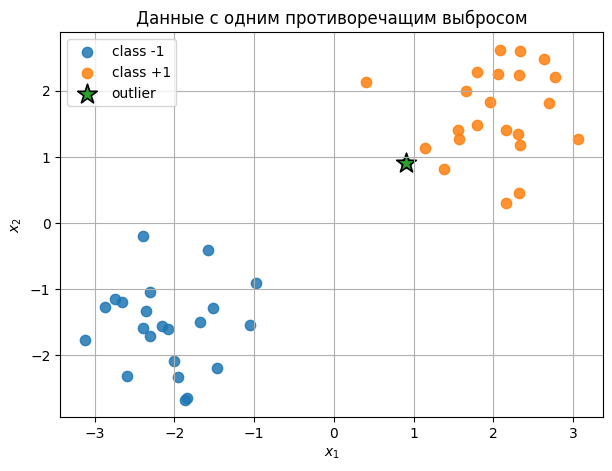

In [3]:
# Данные для задачи 1
X_out, y_out, X_bad = make_outlier_data(random_state=RANDOM_STATE, n_bad=1)

fig, ax = plt.subplots(figsize=(7, 5))
plot_points_2d(X_out, y_out, ax=ax, title="Данные с одним противоречащим выбросом")
ax.scatter(
    X_bad[:, 0], X_bad[:, 1],
    s=220, marker="*", edgecolors="black", linewidths=1.2,
    label="outlier"
)
ax.legend()
plt.show()


In [4]:
# TODO:
# 1. Пройдите по сетке C_values.
# 2. Для каждого C обучите SVC(kernel="linear", C=C).
# 3. Соберите таблицу со столбцами:
#    C, ||w||, margin_width = 2/||w||, n_support_vectors, mean_hinge, train_accuracy.
# 4. Попробуйте найти диапазон C, где поведение модели резко меняется.

C_values = [1e-2, 1e-1, 1, 10, 1e2, 1e3]

results_outlier = pd.DataFrame(
    columns=[
        "C",
        "||w||",
        "margin_width",
        "n_support_vectors",
        "mean_hinge",
        "train_accuracy",
    ]
)

for c in C_values:
  cls = SVC(C=c, kernel='linear', random_state=RANDOM_STATE) # создаем линейный классификатор SVM
  cls.fit(X_out, y_out)
  y_pred = cls.predict(X_out)
  norm_w = np.linalg.norm(cls.coef_[0])
  margin_width = 2 / norm_w
  y_logical = np.where(y_out == cls.classes_[1], 1, -1)
  n_support_vectors = cls.n_support_.sum()
  decisions = cls.decision_function(X=X_out)
  hinge_loss_mean = np.mean(np.maximum(0, 1 - y_logical*decisions))
  train_accuracy = accuracy_score(y_out, y_pred)
  row = {
      "C": c,
      "||w||": norm_w,
      "margin_width" : margin_width,
      "n_support_vectors": n_support_vectors,
      "mean_hinge": hinge_loss_mean,
      "train_accuracy":train_accuracy,
  }
  results_outlier = pd.concat([results_outlier, pd.DataFrame([row])])
results_outlier


/tmp/ipykernel_47887/1148197490.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_outlier = pd.concat([results_outlier, pd.DataFrame([row])])


,C,||w||,margin_width,n_support_vectors,mean_hinge,train_accuracy
0,0.01,0.382004,5.235542,22,0.125922,0.977778
0,0.10,0.627182,3.188865,7,0.043958,0.977778
0,1.00,0.685771,2.916426,4,0.039397,0.977778
0,10.00,3.312000,0.603865,3,0.020068,1.000000
0,100.00,6.037845,0.331244,3,0.000008,1.000000
0,1000.00,6.037845,0.331244,3,0.000008,1.000000


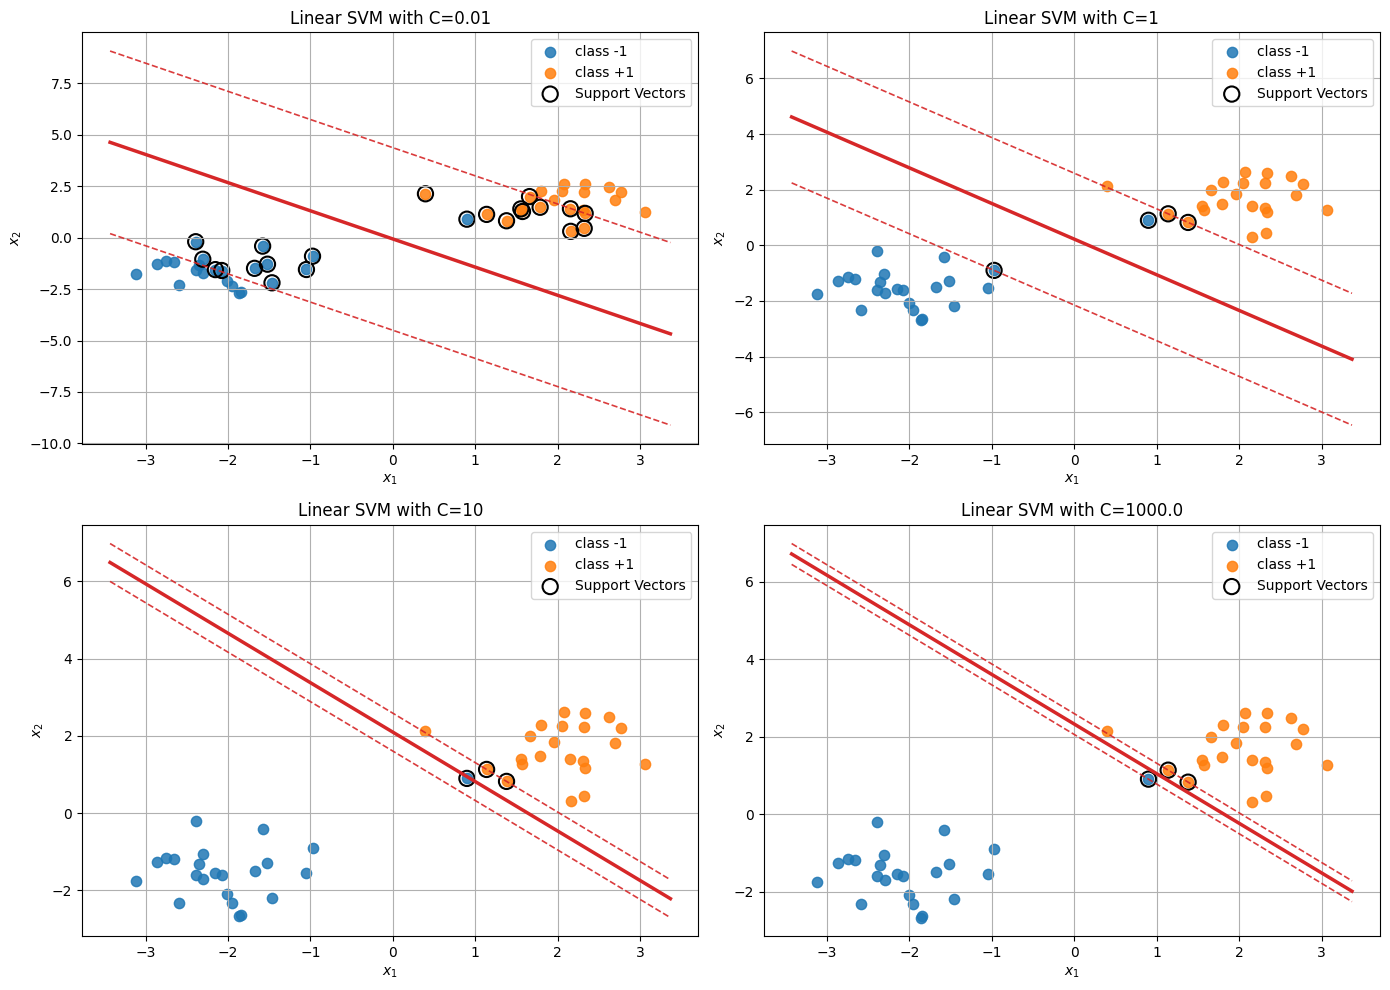

In [5]:
# TODO:
# Выберите 3-4 характерных значения C и постройте для них графики:
# - точки двух классов;
# - разделяющая прямая;
# - margin-линии;
# - support vectors.
#
# Подсказка:
# model.support_vectors_ содержит опорные векторы.

selected_C = [1e-2, 1, 10, 1e3]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, c in enumerate(selected_C):
    ax = axes[i]
    cls = SVC(C=c, kernel='linear', random_state=RANDOM_STATE)
    cls.fit(X_out, y_out)

    plot_points_2d(X_out, y_out, ax=ax, title=f'Linear SVM with C={c}')

    xlim = ax.get_xlim()
    plot_separator_and_margins(cls, ax, xlim)

    # Plot support vectors
    ax.scatter(
        cls.support_vectors_[:, 0],
        cls.support_vectors_[:, 1],
        s=120, facecolors='none', edgecolors='k', linewidths=1.5,
        label='Support Vectors'
    )

    ax.legend()

plt.tight_layout()
plt.show()

### Комментарий к задаче 1

Коротко ответьте письменно:

1. При каких $C$ выброс вносит минимальный вклад в решение?
2. При каких $C$ граница начинает заметно поворачиваться?
3. Почему увеличение $C$ часто приводит к **сужению** полосы margin?


1. При маленьком значении параметра $C$ выброс не влияет на границу решения. Наша модель строит разделяющую поверхность и ошибается как раз на вот этом вот выбросе.

2. По мере увеличения C наша модель начинает подстраиваться под выброс и старается провести границу , которая отнесла бы выброс к правильному классу.При $C=1000$ SVC проводит границу опираясь как раз на значение выброса в качестве опорного вектора в классе синих точек.

3. Потому что мы минимизируем $\min_{w, b, \xi} \left( \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i \right)$; $y_i(w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$ $, M = \frac{2}{\|w\|}
$

Если объект находится на границе маржина или дальше от неё (в своей зоне), то $\xi=0$

.
Если объект нарушил границу своего маржина, то
 — это расстояние, на которое он углубился внутрь зазора в сторону чужого класса $\xi>0$

Константа C управляет тем, насколько важно, чтобы модель не ошибалась на таких точках.

При росте $C$ приоритет смещается на минимизацию суммы ошибок $\sum \xi_i$. Чтобы сделать ошибки минимальными, алгоритму приходится жестко соблюдать условие:

$$y_i(w^T x_i + b) \geq 1 - \xi_i \quad (\text{где } \xi_i \to 0)$$

Это вынуждает модель «подтягивать» пунктирные линии как можно ближе к точкам обучающей выборки, что приводит к **росту нормы весов $\|w\|$**.

Так как ширина маржина обратно пропорциональна норме весов:

$$M = \frac{2}{\|w\|}$$

Рост $\|w\|$ неизбежно вызывает **сужение** полосы $M$.



## 2. Геометрия линейного SVM в больших размерностях

Рассмотрим вероятностную модель
$$
Y \in \{-1,1\}, \qquad \mathbb{P}(Y=1)=\mathbb{P}(Y=-1)=\frac12,
$$
$$
X = \mu Y e_1 + \sigma Z, \qquad Z \sim \mathcal{N}(0, I_d),
$$
где $e_1=(1,0,\dots,0)$.

Здесь **только первая координата** несёт полезный сигнал, а остальные $d-1$ координат — чистый шум.

Требуется:

1. Аналитически вывести байесовский классификатор.
2. Вычислить байесовскую ошибку.
3. Объяснить, почему эта ошибка **не зависит** от размерности $d$.
4. Зафиксировать
$$
n_{\mathrm{train}}=80,\qquad n_{\mathrm{test}}=5000,\qquad R=30.
$$
Для каждого
$$
d\in\{2,5,10,20,50,100\}
$$
30 раз независимо:
- сгенерировать обучающую и тестовую выборки из указанной модели;
- обучить линейный SVM на обучающей выборке;
- записать `train accuracy`, `test accuracy`, число support vectors и факт линейной разделимости обучающей выборки.

Затем для каждого $d$ усреднить результаты по 30 повторам и построить графики зависимости от $d$.

Основная цель — понять различие между:

- **истинной статистической сложностью** задачи;
- **геометрической лёгкостью** линейного разделения train-набора.


### Теоретическая часть

Подсказка: сравните условные плотности $p(x \mid Y=1)$ и $p(x \mid Y=-1)$.
Удобно взять логарифм отношения правдоподобий.

В этой модели
$$
X \mid (Y=1) \sim \mathcal{N}(\mu e_1, \sigma^2 I_d),
\qquad
X \mid (Y=-1) \sim \mathcal{N}(-\mu e_1, \sigma^2 I_d).
$$

Нужно показать, что байесовское правило зависит только от первой координаты.


## Аналитический вывод байесовского классификатора

Для вывода оптимального классификатора воспользуемся логарифмом отношения правдоподобий (log-likelihood ratio). Согласно условию, априорные вероятности классов равны: $P(Y=1) = P(Y=-1) = 1/2$.

Плотность многомерного нормального распределения:
$$ p(\mathbf{x} | \mathbf{m}, \sigma^2 I) = \frac{1}{(2\pi)^{d/2} \sigma^d} \exp\left( -\frac{\|\mathbf{x} - \mathbf{m}\|^2}{2\sigma^2} \right) $$

Сравнение плотностей для классов Y=1 (центр $\mu * e_1$) и $Y=-1$ (центр $-\mu * e_1$):
$$
\ln \frac{p(\mathbf{x} | Y=1)}{p(\mathbf{x} | Y=-1)} = \ln \frac{\exp\left( -\frac{\|\mathbf{x} - \mu \mathbf{e}_1\|^2}{2\sigma^2} \right)}{\exp\left( -\frac{\|\mathbf{x} + \mu \mathbf{e}_1\|^2}{2\sigma^2} \right)}
$$
Упрощение выражения:
$$
L(\mathbf{x}) = \frac{1}{2\sigma^2} \left( \|\mathbf{x} + \mu \mathbf{e}_1\|^2 - \|\mathbf{x} - \mu \mathbf{e}_1\|^2 \right)
$$

Раскрытие квадратов норм (скалярное произведение):
$$
\|\mathbf{x} + \mu \mathbf{e}_1\|^2 = \|\mathbf{x}\|^2 + 2\mu \langle \mathbf{x}, \mathbf{e}_1 \rangle + \mu^2 \|\mathbf{e}_1\|^2
$$
$$
\|\mathbf{x} - \mu \mathbf{e}_1\|^2 = \|\mathbf{x}\|^2 - 2\mu \langle \mathbf{x}, \mathbf{e}_1 \rangle + \mu^2 \|\mathbf{e}_1\|^2
$$
Результат после сокращения:
$$
L(\mathbf{x}) = \frac{1}{2\sigma^2} \left( 4\mu \langle \mathbf{x}, \mathbf{e}_1 \rangle \right) = \frac{2\mu x_1}{\sigma^2}
$$
Решающее правило Байеса:
$$
\hat{Y}_{Bayes}(\mathbf{x}) = \text{sign}(x_1)
$$

## Байесовская ошибка

Ошибка через интеграл плотности первой координаты:
$$
P_{err} = P(x_1 < 0 | Y=1)
$$

Так как $x1 $~$ 𝓝(\mu, \sigma^2)$, переходим к стандартному распределению:
$$
P(x_1 < 0) = P\left( \frac{x_1 - \mu}{\sigma} < \frac{0 - \mu}{\sigma} \right)
$$

Итоговая формула:
$$
P_{err} = \Phi\left( -\frac{\mu}{\sigma} \right)
$$

## Независимость от $d$
Ошибка не зависит от размерности $d$, так как по условию только первая координата $x_1$ несет полезный сигнал (разные математические ожидания для разных классов). Остальные $d-1$ координат являются шумом $N(0, 1)$, распределение которого идентично для обоих классов. При вычислении отношения правдоподобий вклады от этих координат полностью сокращаются, и они не влияют на теоретический предел точности.

In [6]:
# Параметры эксперимента для задачи 2
mu = 0.7
sigma = 1.0
dims = [2, 5, 10, 20, 50, 100]
n_train = 80
n_test = 500
n_repeats = 3
C_hd = 1.0

print("Проверьте аналитически, что Bayes error должна равняться Phi(-mu/sigma).")
print("Для каждого d эксперимент нужно повторить n_repeats раз независимо.")


Проверьте аналитически, что Bayes error должна равняться Phi(-mu/sigma).
Для каждого d эксперимент нужно повторить n_repeats раз независимо.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Константы из условия
mu = 0.7
sigma = 1.0
dims = [2, 5, 10, 20, 50, 100]
n_train = 80
n_test = 300
n_repeats = 2
C_hd = 1.0
RANDOM_STATE = 42

results_list_hd = []

# Функция генерации (максимально быстрая через numpy)
def generate_hd_sample(n, d, mu, sigma, rng):
    y = rng.choice([-1, 1], size=n)
    # Генерируем весь шум сразу
    X = rng.normal(0, sigma, size=(n, d))
    # Добавляем сигнал только в первую колонку
    X[:, 0] += mu * y
    return X, y

for d_val in dims:
    print(f"Processing d={d_val}...")
    for r in range(n_repeats):
        print(f'start for d={d_val} r={r}')
        rng = np.random.default_rng(RANDOM_STATE + r)

        # 1. Генерация
        print('генерация запущена')
        X_train, y_train = generate_hd_sample(n_train, d_val, mu, sigma, rng)
        X_test, y_test = generate_hd_sample(n_test, d_val, mu, sigma, rng)
        print('генерация выполнена')

        # 2. Обучение основного SVM
        # Используем SVC(kernel='linear'), так как нам нужно число опорных векторов (n_support_)
        # LinearSVC их не возвращает напрямую.
        cls = SVC(C=C_hd, kernel='linear', random_state=RANDOM_STATE + r)
        print('обучение cls')
        cls.fit(X_train, y_train)

        # 3. Метрики (score быстрее, чем predict + accuracy_score)
        print('Предсказания на трейне...')
        train_accuracy = cls.score(X_train, y_train)
        test_accuracy = cls.score(X_test, y_test)
        n_support_vectors = cls.n_support_.sum()

        # 4. Линейная разделимость (Hard Margin)
        # 1e6 достаточно, чтобы проверить разделимость при малых N
        print('обучение cls C=1e6')

        cls_separable = SVC(C=1e6, kernel='linear', random_state=RANDOM_STATE + r)
        cls_separable.fit(X_train, y_train)
        print('Предсказания на тесте...')
        separable_train = (cls_separable.score(X_train, y_train) >= 0.999)
        results_list_hd.append({
            "d": d_val,
            "repeat": r,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
            "n_support_vectors": n_support_vectors,
            "separable_train": int(separable_train),
        })
        print('Добавили запись в список')


results_hd = pd.DataFrame(results_list_hd)

# Агрегируем результаты для наглядности
summary = results_hd.groupby('d').agg({
    'train_accuracy': 'mean',
    'test_accuracy': 'mean',
    'n_support_vectors': 'mean',
    'separable_train': 'mean'
})

print("\nУсредненные результаты:")
print(summary)

Processing d=2...
start for d=2 r=0
генерация запущена
генерация выполнена
обучение cls
Предсказания на трейне...
обучение cls C=1e6
Предсказания на тесте...
Добавили запись в список
start for d=2 r=1
генерация запущена
генерация выполнена
обучение cls
Предсказания на трейне...
обучение cls C=1e6
Предсказания на тесте...
Добавили запись в список
Processing d=5...
start for d=5 r=0
генерация запущена
генерация выполнена
обучение cls
Предсказания на трейне...
обучение cls C=1e6
Предсказания на тесте...
Добавили запись в список
start for d=5 r=1
генерация запущена
генерация выполнена
обучение cls
Предсказания на трейне...
обучение cls C=1e6


Processing dimension d=2...


In [ ]:
# TODO:
# Для каждого d усредните результаты по всем повторам и постройте графики:
#   1. средние train/test accuracy;
#   2. среднее число support vectors;
#   3. долю линейно разделимых train-выборок:
#         separable_train_rate(d) = average of separable_train over repeats.
#
# После этого кратко сопоставьте результаты
# с аналитическим выводом байесовского классификатора.

# Ваш код здесь


### Комментарий к задаче 2

Коротко обсудите:

1. Почему истинная сложность задачи в этой модели не зависит от $d$?
2. Почему при росте $d$ train-выборка может становиться легче линейно разделимой?
3. Почему это **не означает**, что test accuracy обязана монотонно расти?